In [ ]:
# Import pandas for data manipulation
import pandas as pd
# Import numpy for numerical operations
import numpy as np

# Load the bank customer churn dataset from CSV file
df = pd.read_csv('Bank Customer Churn Prediction.csv')
# Display the first 5 rows to inspect the data structure
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Drop customer_id and country columns as they are not needed for modeling
df = df.drop(['customer_id','country'], axis=1)
# Display the first 5 rows of the cleaned dataset
df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Import preprocessing tools for data standardization
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Import K-means clustering algorithm
from sklearn.cluster import KMeans
# Import metrics to evaluate model performance
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Import optimization function to align cluster labels with true labels
from scipy.optimize import linear_sum_assignment

# Create a copy of the dataframe to work with
df_kmeans = df.copy()
# Initialize a label encoder for converting categorical gender to numeric values
le_gender = LabelEncoder()
# Convert gender column (Male/Female) to numeric values (0/1)
df_kmeans['gender'] = le_gender.fit_transform(df_kmeans['gender'])

# Extract all features (independent variables) except churn
X = df_kmeans.drop('churn', axis=1)
# Extract the target variable (churn column)
y = df_kmeans['churn']

# Initialize the StandardScaler to normalize features to have mean 0 and std 1
scaler = StandardScaler()
# Fit the scaler and transform the features to standardized values
X_scaled = scaler.fit_transform(X)
# Create K-means model with 2 clusters (for binary churn prediction)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
# Fit the model and get cluster assignments for each sample
clusters = kmeans.fit_predict(X_scaled)

# Create confusion matrix to compare predicted clusters with actual churn labels
conf_mat = confusion_matrix(y, clusters)
# Use linear sum assignment to find the optimal mapping between clusters and churn labels
row_ind, col_ind = linear_sum_assignment(-conf_mat)
# Create a dictionary mapping cluster labels to churn labels
cluster_to_churn = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
# Apply the mapping to align predicted clusters with actual churn classes
aligned_clusters = np.array([cluster_to_churn[c] for c in clusters])

# Calculate the accuracy of the aligned clusters compared to actual churn
accuracy = accuracy_score(y, aligned_clusters)
# Print the accuracy score formatted to 4 decimal places
print(f"K-means Accuracy: {accuracy:.4f}")
# Print the confusion matrix showing true positives, false positives, etc.
print(f"\nConfusion Matrix:\n{confusion_matrix(y, aligned_clusters)}")
# Print detailed classification metrics including precision, recall, and F1-score
print(f"\nClassification Report:\n{classification_report(y, aligned_clusters, target_names=['No Churn', 'Churn'])}")


K-means Accuracy: 0.5214

Confusion Matrix:
[[4472 3491]
 [1295  742]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.78      0.56      0.65      7963
       Churn       0.18      0.36      0.24      2037

    accuracy                           0.52     10000
   macro avg       0.48      0.46      0.44     10000
weighted avg       0.65      0.52      0.57     10000



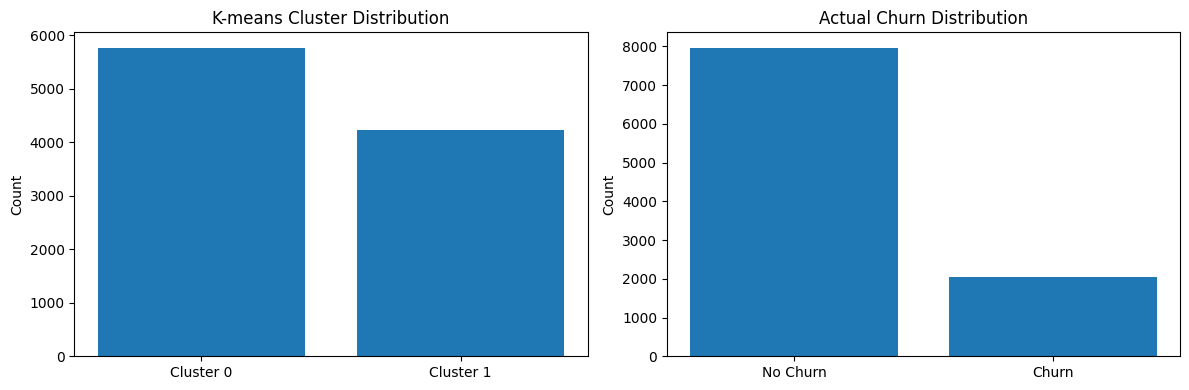

In [ ]:
# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns of subplots (12 inches wide, 4 inches tall)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Create a bar chart showing the count of samples in each cluster
axes[0].bar(['Cluster 0', 'Cluster 1'], np.bincount(clusters))
# Set the title for the first subplot
axes[0].set_title('K-means Cluster Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Create a bar chart showing the count of churners vs non-churners in actual data
axes[1].bar(['No Churn', 'Churn'], np.bincount(y))
# Set the title for the second subplot
axes[1].set_title('Actual Churn Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots automatically
plt.tight_layout()
# Display the figure
plt.show()


In [ ]:
# Import Gradient Boosting classifier (ensemble method combining weak learners)
from sklearn.ensemble import GradientBoostingClassifier
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing with random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
# Train the model on the training data
gb_model.fit(X_train, y_train)

# Make predictions on the test set
gb_pred = gb_model.predict(X_test)
# Calculate the accuracy by comparing predictions with actual test labels
gb_accuracy = accuracy_score(y_test, gb_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
# Print the confusion matrix for detailed performance analysis
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, gb_pred)}")
# Print precision, recall, and F1-score for each class
print(f"\nClassification Report:\n{classification_report(y_test, gb_pred, target_names=['No Churn', 'Churn'])}")


Gradient Boosting Accuracy: 0.8660

Confusion Matrix:
[[1552   55]
 [ 213  180]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92      1607
       Churn       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



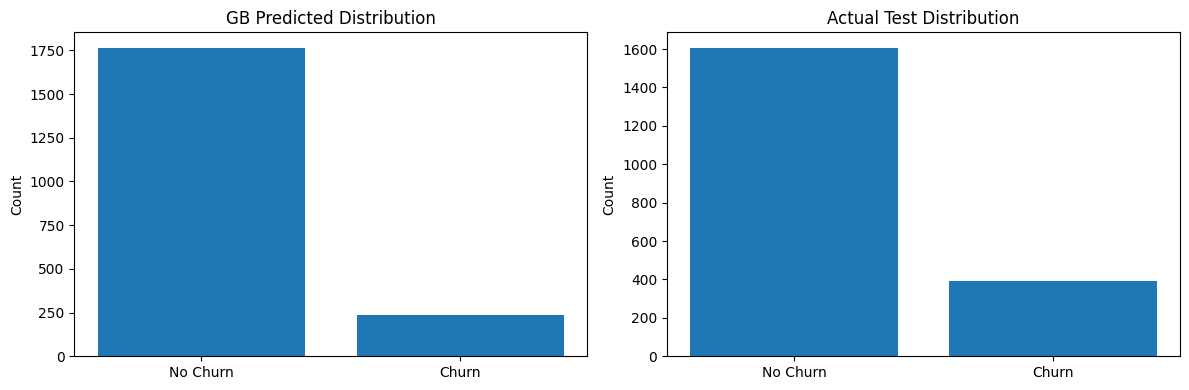

In [ ]:
# Create a figure with 1 row and 2 columns of subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of Gradient Boosting predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(gb_pred))
# Set title for predicted distribution
axes[0].set_title('GB Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots
plt.tight_layout()
# Display the figure
plt.show()


In [ ]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lr_model = LinearRegression()
# Train the model on the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test set (outputs continuous values)
lr_pred_raw = lr_model.predict(X_test)
# Round continuous predictions to nearest integer (0 or 1) for classification
lr_pred = np.round(lr_pred_raw).astype(int)
# Calculate accuracy by comparing rounded predictions with actual labels
lr_accuracy = accuracy_score(y_test, lr_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"Linear Regression Accuracy: {lr_accuracy:.4f}")
# Print the confusion matrix showing prediction performance breakdown
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, lr_pred)}")
# Print detailed metrics including precision, recall, and F1-score
print(f"\nClassification Report:\n{classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn'])}")


Linear Regression Accuracy: 0.8040

Confusion Matrix:
[[1578   29]
 [ 363   30]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.98      0.89      1607
       Churn       0.51      0.08      0.13       393

    accuracy                           0.80      2000
   macro avg       0.66      0.53      0.51      2000
weighted avg       0.75      0.80      0.74      2000



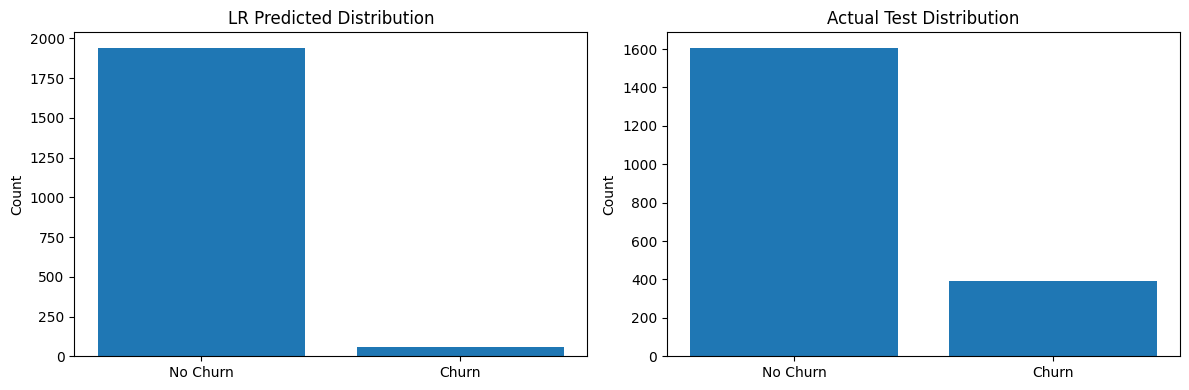

In [ ]:
# Create a figure with 1 row and 2 columns for comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of Linear Regression predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(lr_pred))
# Set title for the predicted distribution
axes[0].set_title('LR Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for the actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots
plt.tight_layout()
# Display the figure
plt.show()


In [ ]:
# Import Logistic Regression classifier (linear classification model)
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with max iterations set to 1000
log_model = LogisticRegression(random_state=42, max_iter=1000)
# Train the model on the training data
log_model.fit(X_train, y_train)

# Make predictions on the test set
log_pred = log_model.predict(X_test)
# Calculate accuracy by comparing predictions with actual test labels
log_accuracy = accuracy_score(y_test, log_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
# Print the confusion matrix for detailed performance analysis
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, log_pred)}")
# Print precision, recall, and F1-score for each class
print(f"\nClassification Report:\n{classification_report(y_test, log_pred, target_names=['No Churn', 'Churn'])}")


Logistic Regression Accuracy: 0.8145

Confusion Matrix:
[[1562   45]
 [ 326   67]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.97      0.89      1607
       Churn       0.60      0.17      0.27       393

    accuracy                           0.81      2000
   macro avg       0.71      0.57      0.58      2000
weighted avg       0.78      0.81      0.77      2000



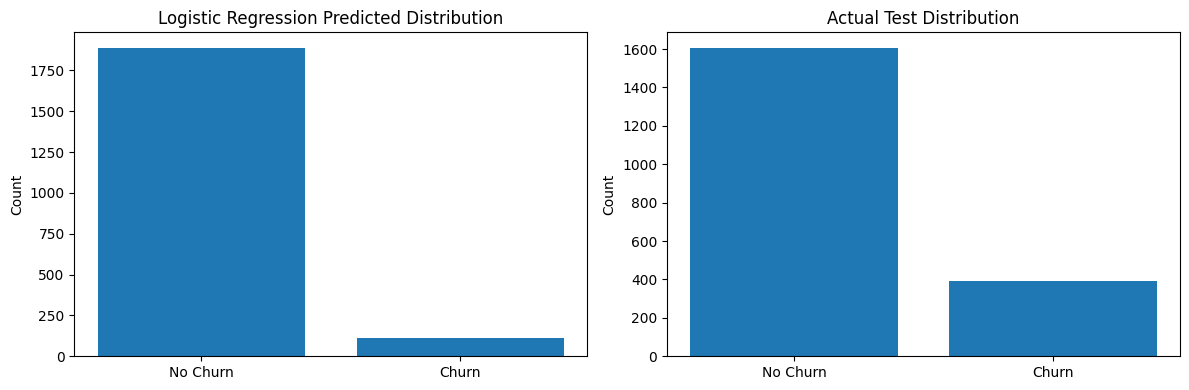

In [ ]:
# Create a figure with 1 row and 2 columns for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of Logistic Regression predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(log_pred))
# Set title for the predicted distribution
axes[0].set_title('Logistic Regression Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for the actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots automatically
plt.tight_layout()
# Display the figure
plt.show()


In [ ]:
# Import Gaussian Naive Bayes classifier (probabilistic classification model)
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()
# Train the model on the training data
nb_model.fit(X_train, y_train)

# Make predictions on the test set
nb_pred = nb_model.predict(X_test)
# Calculate accuracy by comparing predictions with actual test labels
nb_accuracy = accuracy_score(y_test, nb_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
# Print the confusion matrix showing true positives, false positives, etc.
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, nb_pred)}")
# Print detailed metrics including precision, recall, and F1-score for each class
print(f"\nClassification Report:\n{classification_report(y_test, nb_pred, target_names=['No Churn', 'Churn'])}")


Naive Bayes Accuracy: 0.8265

Confusion Matrix:
[[1565   42]
 [ 305   88]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.97      0.90      1607
       Churn       0.68      0.22      0.34       393

    accuracy                           0.83      2000
   macro avg       0.76      0.60      0.62      2000
weighted avg       0.81      0.83      0.79      2000



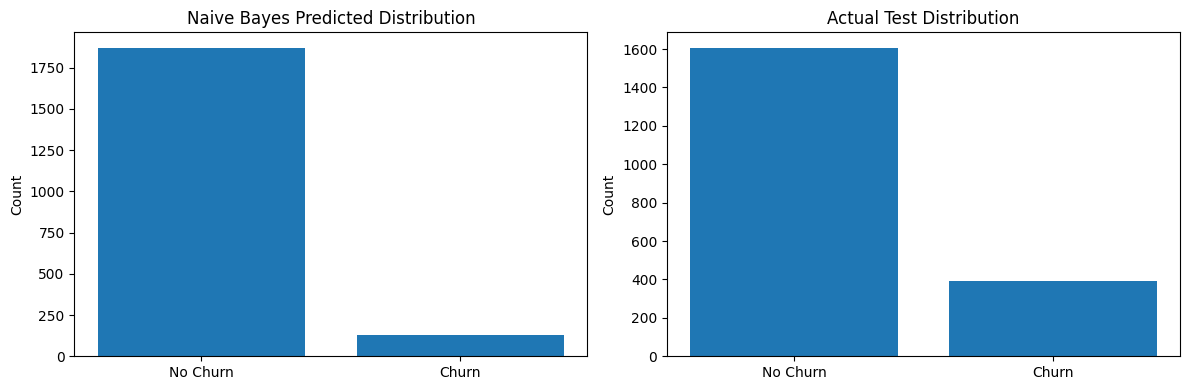

In [ ]:
# Create a figure with 1 row and 2 columns for comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of Naive Bayes predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(nb_pred))
# Set title for the predicted distribution
axes[0].set_title('Naive Bayes Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for the actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots automatically
plt.tight_layout()
# Display the figure
plt.show()


In [26]:
# Create a comparison table of all models
# Initialize an empty list to store model results
model_results = []

# Add K-means results (using aligned clusters from full dataset)
model_results.append({
    'Model': 'K-means',
    'Accuracy': f"{accuracy:.4f}",
    'Type': 'Unsupervised'
})

# Add Gradient Boosting results
model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': f"{gb_accuracy:.4f}",
    'Type': 'Supervised'
})

# Add Linear Regression results
model_results.append({
    'Model': 'Linear Regression',
    'Accuracy': f"{lr_accuracy:.4f}",
    'Type': 'Supervised'
})

# Add Logistic Regression results
model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': f"{log_accuracy:.4f}",
    'Type': 'Supervised'
})

# Add Naive Bayes results
model_results.append({
    'Model': 'Naive Bayes',
    'Accuracy': f"{nb_accuracy:.4f}",
    'Type': 'Supervised'
})

# Add CatBoost results
model_results.append({
    'Model': 'CatBoost',
    'Accuracy': f"{cb_accuracy:.4f}",
    'Type': 'Supervised'
})

# Add XGBoost results
model_results.append({
    'Model': 'XGBoost',
    'Accuracy': f"{xgb_accuracy:.4f}",
    'Type': 'Supervised'
})

# Create a DataFrame from the results list
comparison_df = pd.DataFrame(model_results)

# Sort by accuracy in descending order to show best models first
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add a rank column starting from 1
comparison_df.insert(0, 'Rank', range(1, len(comparison_df) + 1))

# Display the comparison table
print("\n" + "="*60)
print("MODEL COMPARISON TABLE - CUSTOMER CHURN PREDICTION")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)



MODEL COMPARISON TABLE - CUSTOMER CHURN PREDICTION
 Rank               Model Accuracy         Type
    1   Gradient Boosting   0.8660   Supervised
    2            CatBoost   0.8625   Supervised
    3             XGBoost   0.8455   Supervised
    4         Naive Bayes   0.8265   Supervised
    5 Logistic Regression   0.8145   Supervised
    6   Linear Regression   0.8040   Supervised
    7             K-means   0.5214 Unsupervised


In [22]:
# Import XGBoost classifier (gradient boosting with advanced features)
from xgboost import XGBClassifier

# Initialize XGBoost model with random state for reproducibility
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', verbose=0)
# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred = xgb_model.predict(X_test)
# Calculate accuracy by comparing predictions with actual test labels
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
# Print the confusion matrix for detailed performance analysis
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, xgb_pred)}")
# Print precision, recall, and F1-score for each class
print(f"\nClassification Report:\n{classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn'])}")


XGBoost Accuracy: 0.8455

Confusion Matrix:
[[1509   98]
 [ 211  182]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.94      0.91      1607
       Churn       0.65      0.46      0.54       393

    accuracy                           0.85      2000
   macro avg       0.76      0.70      0.72      2000
weighted avg       0.83      0.85      0.84      2000



c:\Users\junu\Documents\Python\pattern-lab-exam\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:37:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


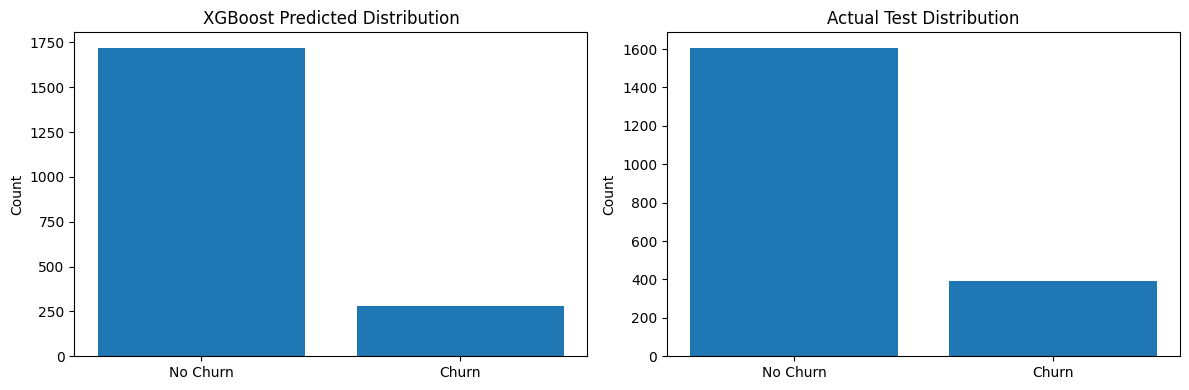

In [23]:
# Create a figure with 1 row and 2 columns for XGBoost visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of XGBoost predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(xgb_pred))
# Set title for the predicted distribution
axes[0].set_title('XGBoost Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for the actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots automatically
plt.tight_layout()
# Display the figure
plt.show()


In [24]:
# Import CatBoost classifier (gradient boosting optimized for categorical features)
from catboost import CatBoostClassifier

# Initialize CatBoost model with random state for reproducibility
cb_model = CatBoostClassifier(random_state=42, verbose=0)
# Train the model on the training data
cb_model.fit(X_train, y_train)

# Make predictions on the test set
cb_pred = cb_model.predict(X_test)
# Calculate accuracy by comparing predictions with actual test labels
cb_accuracy = accuracy_score(y_test, cb_pred)

# Print the accuracy score formatted to 4 decimal places
print(f"CatBoost Accuracy: {cb_accuracy:.4f}")
# Print the confusion matrix for detailed performance analysis
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, cb_pred)}")
# Print precision, recall, and F1-score for each class
print(f"\nClassification Report:\n{classification_report(y_test, cb_pred, target_names=['No Churn', 'Churn'])}")


CatBoost Accuracy: 0.8625

Confusion Matrix:
[[1545   62]
 [ 213  180]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92      1607
       Churn       0.74      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



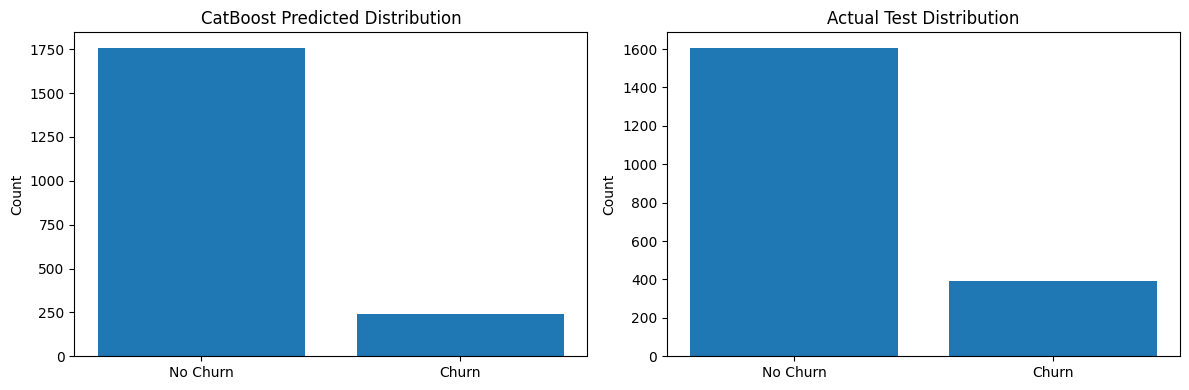

In [25]:
# Create a figure with 1 row and 2 columns for CatBoost visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of CatBoost predictions
axes[0].bar(['No Churn', 'Churn'], np.bincount(cb_pred))
# Set title for the predicted distribution
axes[0].set_title('CatBoost Predicted Distribution')
# Label the y-axis
axes[0].set_ylabel('Count')

# Plot the distribution of actual churn values in the test set
axes[1].bar(['No Churn', 'Churn'], np.bincount(y_test))
# Set title for the actual distribution
axes[1].set_title('Actual Test Distribution')
# Label the y-axis
axes[1].set_ylabel('Count')

# Adjust spacing between subplots automatically
plt.tight_layout()
# Display the figure
plt.show()
